# Brain-Act Subject-Level State Analysis (Template Identity + SF Rank)

This notebook uses a **hybrid strategy**:

1. Learn a shared set of 5 canonical template states (state "type").
2. For each subject/seed, map local states to templates by centroid similarity.
3. Compute SF coupling for each mapped template state against that subject's SC.
4. Re-rank template states within each subject/seed by SF coupling (low → high).

This preserves canonical state identity while also allowing SF-ordered occupancy analysis.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu, spearmanr

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tvbtoolkit import (
    summarize_brain_states,
    load_subject_structural,
    safe_pearson,
    fit_state_templates,
    align_states_to_templates,
)


In [2]:
OUT_ROOT = PROJECT_ROOT / 'notebooks' / 'outputs' / 'brain_act_subject_specific'
SIM_ROOT = OUT_ROOT / 'simulations'
MET_ROOT = OUT_ROOT / 'metrics'
FIG_ROOT = OUT_ROOT / 'figures'
INT_ROOT = OUT_ROOT / 'metrics' / 'state_alignment'
FIG_ROOT.mkdir(parents=True, exist_ok=True)
INT_ROOT.mkdir(parents=True, exist_ok=True)

COHORTS = ('control', 'mcs', 'uws')
K_STATES = 5
TRIM_EDGE_SAMPLES = 9
N_INIT_SUBJECT = 20
N_INIT_TEMPLATE = 48
RANDOM_SEED = 7

# Template source:
# - 'control_only': canonical healthy-state template basis
# - 'all_cohorts': pooled template basis
TEMPLATE_SOURCE = 'control_only'

# Dataset root for structural matrices (used to compute SF coupling).
DATASET_ROOT_CANDIDATE = PROJECT_ROOT / 'data' / 'brain_act' / 'converted'
DATASET_ROOT = DATASET_ROOT_CANDIDATE if DATASET_ROOT_CANDIDATE.exists() else None

# Performance controls
USE_SAVED_CENTERS = True
ALLOW_FALLBACK_RECOMPUTE = False
MAX_SUBJECTS_PER_COHORT = None  # set e.g. 5 for quick smoke test

## Utility functions


In [3]:
def parse_seed_from_name(p: Path) -> int:
    stem = p.stem  # seed_000
    parts = stem.split('_')
    return int(parts[-1])


def holm_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = pvals.size
    order = np.argsort(pvals)
    out = np.empty(m, dtype=float)
    prev = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvals[idx]
        adj = max(adj, prev)
        out[idx] = min(adj, 1.0)
        prev = out[idx]
    return out


def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return float((gt - lt) / (x.size * y.size))


def cohort_stats_unpaired(values_by_cohort, metric_name, cohorts=COHORTS):
    vals = [np.asarray(values_by_cohort[c], dtype=float) for c in cohorts]
    H, p_kw = kruskal(*vals)

    pairs = [(cohorts[0], cohorts[1]), (cohorts[0], cohorts[2]), (cohorts[1], cohorts[2])]
    rows = []
    p_raw = []
    for a, b in pairs:
        xa = np.asarray(values_by_cohort[a], dtype=float)
        xb = np.asarray(values_by_cohort[b], dtype=float)
        U, p = mannwhitneyu(xa, xb, alternative='two-sided')
        p_raw.append(p)
        rows.append({
            'metric': metric_name,
            'contrast': f'{a} vs {b}',
            'n_a': xa.size,
            'n_b': xb.size,
            'U': float(U),
            'p_raw': float(p),
            'p_holm': np.nan,
            'cliffs_delta': cliffs_delta(xa, xb),
            'median_a': float(np.median(xa)),
            'median_b': float(np.median(xb)),
        })

    for r, pa in zip(rows, holm_correct(p_raw)):
        r['p_holm'] = float(pa)

    omni = pd.DataFrame([{
        'metric': metric_name,
        'test': 'Kruskal-Wallis',
        'H': float(H),
        'p': float(p_kw),
    }])
    pair = pd.DataFrame(rows)
    return omni, pair


def jitter(n, width=0.08, seed=0):
    rng = np.random.default_rng(seed)
    return rng.uniform(-width, width, size=n)


def plot_subject_metric(ax, df, value_col, title, ylabel, cohorts=COHORTS, colors=None, seed=0):
    if colors is None:
        colors = {'control': '#4C78A8', 'mcs': '#F58518', 'uws': '#54A24B'}
    xs = np.arange(len(cohorts), dtype=float)
    for i, c in enumerate(cohorts):
        vals = df.loc[df['cohort'] == c, value_col].to_numpy(dtype=float)
        if vals.size == 0:
            continue
        ax.scatter(np.full(vals.size, xs[i]) + jitter(vals.size, seed=seed+i), vals,
                   s=24, alpha=0.75, color=colors.get(c, '#666666'))
        med = np.median(vals)
        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)
        ax.plot([xs[i]-0.18, xs[i]+0.18], [med, med], color='black', lw=1.8)
        ax.vlines(xs[i], q1, q3, color='black', lw=1.2)
    ax.set_xticks(xs, [c.upper() for c in cohorts])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

## Load subject state summaries (local states)

Fast path (default): load cached `brain_state_centers` and `brain_state_occupancy`
from per-subject metrics files.

Slow fallback (optional): recompute states from raw seed files if cached centers
are missing (`ALLOW_FALLBACK_RECOMPUTE=True`).

In [4]:
records = []
all_centers = []
missing_centers = []

for cohort in COHORTS:
    cohort_metrics_dir = MET_ROOT / cohort
    if not cohort_metrics_dir.exists():
        continue

    metric_files = sorted([p for p in cohort_metrics_dir.glob('*_metrics.npz') if not p.name.endswith('_cohort_metrics.npz')])
    if MAX_SUBJECTS_PER_COHORT is not None:
        metric_files = metric_files[: int(MAX_SUBJECTS_PER_COHORT)]

    for mf in metric_files:
        sid = mf.stem.replace('_metrics', '')
        m = np.load(mf, allow_pickle=True)
        seeds = np.asarray(m['seeds'], dtype=int) if 'seeds' in m.files else np.array([], dtype=int)
        if seeds.size == 0:
            continue

        has_cached = ('brain_state_centers' in m.files) and ('brain_state_occupancy' in m.files)
        if USE_SAVED_CENTERS and has_cached:
            centers_all = np.asarray(m['brain_state_centers'], dtype=float)
            occ_all = np.asarray(m['brain_state_occupancy'], dtype=float)

            if centers_all.ndim == 3 and occ_all.ndim == 2 and centers_all.shape[0] == occ_all.shape[0]:
                n_seed_eff = min(int(seeds.size), int(centers_all.shape[0]))
                for i in range(n_seed_eff):
                    seed_id = int(seeds[i])
                    centers = np.asarray(centers_all[i], dtype=float)
                    occupancy = np.asarray(occ_all[i], dtype=float)
                    if centers.ndim != 2 or centers.shape[0] != K_STATES or occupancy.shape[0] != K_STATES:
                        continue
                    all_centers.append(centers)
                    for s in range(K_STATES):
                        records.append({
                            'cohort': cohort,
                            'subject_id': sid,
                            'seed': seed_id,
                            'local_state': s,
                            'occupancy': float(occupancy[s]),
                            'source': 'cached_metrics',
                            'center': centers[s].copy(),
                        })
                continue

        if not ALLOW_FALLBACK_RECOMPUTE:
            missing_centers.append((cohort, sid))
            continue

        # Slow fallback: recompute from saved raw seed files
        subject_dir = SIM_ROOT / cohort / sid
        if not subject_dir.exists():
            missing_centers.append((cohort, sid))
            continue

        for seed_id in seeds:
            sf = subject_dir / f'seed_{int(seed_id):03d}.npz'
            if not sf.exists():
                missing_centers.append((cohort, sid))
                continue
            d = np.load(sf, allow_pickle=True)
            x = np.asarray(d['raw'], dtype=float)

            bs = summarize_brain_states(
                x,
                n_states=K_STATES,
                trim_edge_samples=TRIM_EDGE_SAMPLES,
                random_seed=int(seed_id),
                n_init=N_INIT_SUBJECT,
            )

            centers = np.asarray(bs.centers, dtype=float)
            occupancy = np.asarray(bs.occupancy, dtype=float)
            if centers.ndim != 2 or centers.shape[0] != K_STATES:
                continue

            all_centers.append(centers)
            for s in range(K_STATES):
                records.append({
                    'cohort': cohort,
                    'subject_id': sid,
                    'seed': int(seed_id),
                    'local_state': s,
                    'occupancy': float(occupancy[s]),
                    'source': 'fallback_recompute',
                    'center': centers[s].copy(),
                })

if missing_centers and not ALLOW_FALLBACK_RECOMPUTE:
    raise RuntimeError(
        f'Missing cached brain_state_centers for {len(set(missing_centers))} subject(s). '
        'Re-run the Brain-Act simulation notebook after updating TVBToolkit, '
        'or set ALLOW_FALLBACK_RECOMPUTE=True (slow). '
        f'Example missing: {list(set(missing_centers))[:5]}'
    )

if not records:
    raise RuntimeError('No state records found. Check output paths and settings.')

states_df = pd.DataFrame(records)
all_centers_mat = np.vstack(all_centers)

print('records:', states_df.shape)
print('pooled centers:', all_centers_mat.shape)
print('sources:', states_df['source'].value_counts().to_dict())
states_df.head()


records: (1200, 8)
pooled centers: (1200, 4005)
sources: {'cached_metrics': 1200}


,cohort,subject_id,seed,local_state,occupancy,n_timepoints_labelled,source,center
0,control,sub-01,0,0,0.064432,NaN,cached_metrics,"[0.49385953390024706, -0.2928710380371237, 0.5..."
1,control,sub-01,0,1,0.265957,NaN,cached_metrics,"[0.9465752799479239, 0.9089606605704518, 0.957..."
2,control,sub-01,0,2,0.217583,NaN,cached_metrics,"[0.5329081326074009, 0.37270953317764516, 0.64..."
3,control,sub-01,0,3,0.055801,NaN,cached_metrics,"[0.34912789655168047, 0.09285315522981773, 0.0..."
4,control,sub-01,0,4,0.396226,NaN,cached_metrics,"[0.2208982448798854, 0.037912503591946464, 0.2..."


## Fit canonical templates, map local states, then SF-rank per subject

In [5]:
# Choose centroid pool for template fitting
if TEMPLATE_SOURCE == 'control_only':
    control_rows = states_df[states_df['cohort'] == 'control']
    if control_rows.empty:
        raise RuntimeError("TEMPLATE_SOURCE='control_only' but no control rows found.")
    centers_for_templates = np.vstack(control_rows['center'].to_list())
else:
    centers_for_templates = all_centers_mat

templates = fit_state_templates(
    centers_for_templates,
    n_states=K_STATES,
    random_seed=RANDOM_SEED,
    n_init=N_INIT_TEMPLATE,
)


def upper_triangle_vector(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
        raise ValueError(f'Expected square matrix, got {arr.shape}')
    iu = np.triu_indices(arr.shape[0], k=1)
    return np.asarray(arr[iu], dtype=float)


# Subject-level SC damage fractions from saved metrics
# (proportion of zero edges in upper-triangle SC)
damage_rows = []
for cohort in COHORTS:
    cohort_metrics_dir = MET_ROOT / cohort
    if not cohort_metrics_dir.exists():
        continue
    for mf in sorted([p for p in cohort_metrics_dir.glob('*_metrics.npz') if not p.name.endswith('_cohort_metrics.npz')]):
        sid = mf.stem.replace('_metrics', '')
        m = np.load(mf, allow_pickle=True)
        dmg = np.nan
        if 'mask_sc_zero_fraction_upper' in m.files:
            arr = np.asarray(m['mask_sc_zero_fraction_upper'], dtype=float).reshape(-1)
            if arr.size > 0:
                dmg = float(arr[0])
        damage_rows.append({'cohort': cohort, 'subject_id': sid, 'sc_damage_fraction': dmg})

damage_df = pd.DataFrame(damage_rows).drop_duplicates(['cohort', 'subject_id'])


sc_cache = {}
align_rows = []
for (cohort, sid, seed), g in states_df.groupby(['cohort', 'subject_id', 'seed']):
    g2 = g.sort_values('local_state')
    local_centers = np.vstack(g2['center'].to_list())
    local_occ = g2['occupancy'].to_numpy(dtype=float)

    aligned = align_states_to_templates(local_centers, local_occ, templates)
    assign = np.asarray(aligned.assignment_local_to_template, dtype=int)  # local -> template
    sim = np.asarray(aligned.similarity_matrix, dtype=float)

    key = (cohort, sid)
    if key not in sc_cache:
        c, _, _, _ = load_subject_structural(
            subject_id=sid,
            cohort=cohort,
            dataset_root=DATASET_ROOT,
            validate=False,
            enforce_symmetry=True,
            zero_diagonal=True,
        )
        sc_cache[key] = upper_triangle_vector(c)
    sc_vec = sc_cache[key]

    # template-wise values (state type identity preserved)
    template_occ = np.zeros(K_STATES, dtype=float)
    template_sfc = np.full(K_STATES, np.nan, dtype=float)
    template_sim = np.full(K_STATES, np.nan, dtype=float)

    for li, t in enumerate(assign):
        if t < 0:
            continue
        template_occ[t] = local_occ[li]
        template_sfc[t] = safe_pearson(local_centers[li], sc_vec)
        template_sim[t] = sim[li, t]

    # subject-specific SF ordering: low -> high
    order = np.argsort(np.nan_to_num(template_sfc, nan=np.inf))
    template_to_rank = np.empty(K_STATES, dtype=int)
    template_to_rank[order] = np.arange(K_STATES, dtype=int)

    for t in range(K_STATES):
        align_rows.append({
            'cohort': cohort,
            'subject_id': sid,
            'seed': int(seed),
            'template_state': int(t),
            'sf_rank': int(template_to_rank[t]),
            'occupancy_template': float(template_occ[t]),
            'sf_coupling': float(template_sfc[t]),
            'template_similarity': float(template_sim[t]),
            'template_distance': float(1.0 - template_sim[t]) if np.isfinite(template_sim[t]) else np.nan,
        })

aligned_seed_df = pd.DataFrame(align_rows)
aligned_seed_df = aligned_seed_df.merge(damage_df, on=['cohort', 'subject_id'], how='left')

# Subject-level summaries by template identity
subject_template_df = (
    aligned_seed_df
    .groupby(['cohort', 'subject_id', 'template_state'], as_index=False)
    .agg(
        occupancy_subject_mean=('occupancy_template', 'mean'),
        occupancy_subject_std=('occupancy_template', 'std'),
        sf_coupling_subject_mean=('sf_coupling', 'mean'),
        template_similarity_subject_mean=('template_similarity', 'mean'),
        template_distance_subject_mean=('template_distance', 'mean'),
        sc_damage_fraction=('sc_damage_fraction', 'mean'),
    )
)

# Subject-level summaries by SF rank (occupancy axis for requested plots)
subject_rank_df = (
    aligned_seed_df
    .groupby(['cohort', 'subject_id', 'sf_rank'], as_index=False)
    .agg(
        occupancy_subject_mean=('occupancy_template', 'mean'),
        sf_coupling_subject_mean=('sf_coupling', 'mean'),
        template_distance_subject_mean=('template_distance', 'mean'),
        sc_damage_fraction=('sc_damage_fraction', 'mean'),
    )
)

# Full template-resolved view within each SF rank (no dominant-type condensation)
subject_rank_template_df = (
    aligned_seed_df
    .groupby(['cohort', 'subject_id', 'sf_rank', 'template_state'], as_index=False)
    .agg(
        occupancy_subject_mean=('occupancy_template', 'mean'),
        sf_coupling_subject_mean=('sf_coupling', 'mean'),
        template_similarity_subject_mean=('template_similarity', 'mean'),
        template_distance_subject_mean=('template_distance', 'mean'),
        sc_damage_fraction=('sc_damage_fraction', 'mean'),
        n_seed=('seed', 'nunique'),
    )
)

assign_freq_df = (
    aligned_seed_df
    .groupby(['cohort', 'subject_id', 'sf_rank', 'template_state'], as_index=False)
    .size()
    .rename(columns={'size': 'n_assign'})
)
assign_freq_df['assignment_fraction'] = (
    assign_freq_df['n_assign']
    / assign_freq_df.groupby(['cohort', 'subject_id', 'sf_rank'])['n_assign'].transform('sum')
)
subject_rank_template_df = subject_rank_template_df.merge(
    assign_freq_df[['cohort', 'subject_id', 'sf_rank', 'template_state', 'n_assign', 'assignment_fraction']],
    on=['cohort', 'subject_id', 'sf_rank', 'template_state'],
    how='left',
)

# Dominant template identity occupying each SF rank (retained for compact overlays)
dom_rows = []
for (cohort, sid, r), g in aligned_seed_df.groupby(['cohort', 'subject_id', 'sf_rank']):
    vc = g['template_state'].value_counts(normalize=True)
    dom_rows.append({
        'cohort': cohort,
        'subject_id': sid,
        'sf_rank': int(r),
        'dominant_template_state': int(vc.index[0]),
        'dominant_template_fraction': float(vc.iloc[0]),
    })
subject_rank_dom_df = pd.DataFrame(dom_rows)
subject_rank_df = subject_rank_df.merge(subject_rank_dom_df, on=['cohort', 'subject_id', 'sf_rank'], how='left')

# Cohort-level summary matrices for plotting
cohort_rank_template_occ_df = (
    subject_rank_template_df
    .groupby(['cohort', 'sf_rank', 'template_state'], as_index=False)
    .agg(
        mean_occupancy=('occupancy_subject_mean', 'mean'),
        sem_occupancy=('occupancy_subject_mean', lambda v: float(np.std(v, ddof=1) / np.sqrt(max(1, len(v))))),
        mean_assignment_fraction=('assignment_fraction', 'mean'),
    )
)

# SF monotonicity check after ranking
is_monotonic = (
    aligned_seed_df
    .sort_values(['cohort', 'subject_id', 'seed', 'sf_rank'])
    .groupby(['cohort', 'subject_id', 'seed'])['sf_coupling']
    .apply(lambda v: bool(np.all(np.diff(v.to_numpy(dtype=float)) >= -1e-12)))
)

rank_summary = (
    aligned_seed_df
    .groupby(['cohort', 'sf_rank'], as_index=False)
    .agg(
        sf_coupling_mean=('sf_coupling', 'mean'),
        sf_coupling_std=('sf_coupling', 'std'),
        occupancy_mean=('occupancy_template', 'mean'),
        occupancy_std=('occupancy_template', 'std'),
    )
)

print('aligned rows:', aligned_seed_df.shape)
print('subject template rows:', subject_template_df.shape)
print('subject rank rows:', subject_rank_df.shape)
print('subject rank-template rows:', subject_rank_template_df.shape)
print('missing sc_damage_fraction rows:', int(aligned_seed_df['sc_damage_fraction'].isna().sum()))
print('SF monotonic proportion:', float(np.mean(is_monotonic.to_numpy(dtype=float))))
rank_summary.head(), subject_template_df.head(), subject_rank_df.head(), subject_rank_template_df.head()



(    cohort subject_id  seed  template_state  occupancy_aligned  \
 0  control     sub-01     0               0           0.265957   
 1  control     sub-01     0               1           0.217583   
 2  control     sub-01     0               2           0.055801   
 3  control     sub-01     0               3           0.064432   
 4  control     sub-01     0               4           0.396226   
 
    mean_match_similarity  
 0               0.215879  
 1               0.215879  
 2               0.215879  
 3               0.215879  
 4               0.215879  ,
     cohort subject_id  template_state  occupancy_subject_mean  \
 0  control     sub-01               0                0.233440   
 1  control     sub-01               1                0.227820   
 2  control     sub-01               2                0.132142   
 3  control     sub-01               3                0.126321   
 4  control     sub-01               4                0.280276   
 
    occupancy_subject_std  si

## Subject-level LZc / PCI summaries (from saved metrics files)


In [6]:
metric_rows = []
for cohort in COHORTS:
    cdir = MET_ROOT / cohort
    if not cdir.exists():
        continue
    for p in sorted(cdir.glob('*_metrics.npz')):
        if p.name.endswith('_cohort_metrics.npz'):
            continue
        sid = p.stem.replace('_metrics', '')
        m = np.load(p, allow_pickle=True)
        lzc = np.asarray(m['lzc'], dtype=float)
        pci = np.asarray(m['pci_casali_like'], dtype=float)
        metric_rows.append({
            'cohort': cohort,
            'subject_id': sid,
            'lzc_subject_mean': float(np.mean(lzc)),
            'pci_subject_mean': float(np.mean(pci)),
        })

subject_metrics_df = pd.DataFrame(metric_rows)
subject_metrics_df.head()


,cohort,subject_id,lzc_subject_mean,pci_subject_mean
0,control,sub-01,0.423268,0.231321
1,control,sub-02,0.420557,0.204894
2,control,sub-03,0.427415,0.188586
3,control,sub-04,0.430452,0.182008
4,control,sub-05,0.428578,0.187979


## Plots: subject-level summaries (template type + SF rank)

These panels now separate three concepts explicitly:

- **Canonical template type** (`Template 1..5`): shared state centroids fitted from pooled subjects.
- **Subject-specific SF rank** (`Rank 1..5`): each subject's matched template states sorted by SF coupling (low → high).
- **Occupancy**: how much time each subject spends in each matched state.

Interpretation:

- Scatter panels: occupancy per SF rank, with colours showing which canonical template type occupies that rank.
- Assignment-probability heatmaps: `P(template type | SF rank)` for each cohort.
- Occupancy heatmaps: mean occupancy carried by each template type at each SF rank.
- Distance panels: cohort differences in deviation from canonical template centroids (`1 - similarity`).


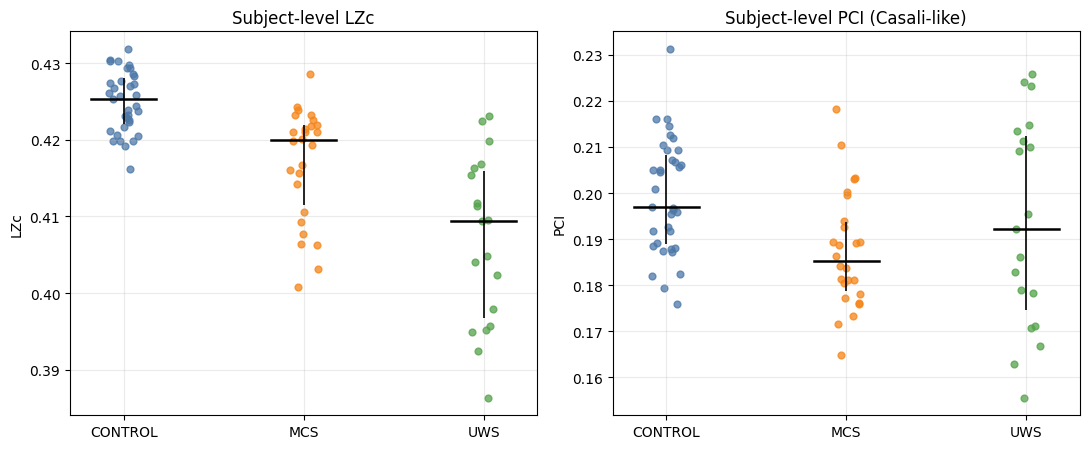

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_subject_metric(axes[0], subject_metrics_df, 'lzc_subject_mean', 'Subject-level LZc', 'LZc')
plot_subject_metric(axes[1], subject_metrics_df, 'pci_subject_mean', 'Subject-level PCI (Casali-like)', 'PCI')
fig.tight_layout()
fig.savefig(FIG_ROOT / 'subject_level_lzc_pci_by_cohort.png', dpi=220)
plt.show()


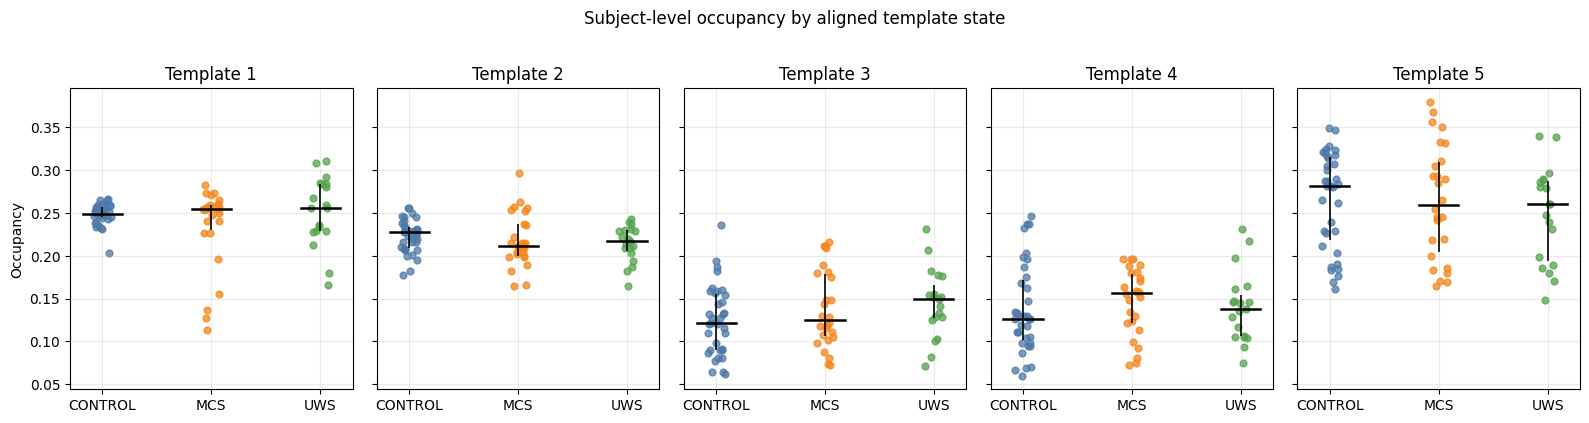

In [8]:
template_colors = {
    0: '#4C78A8',
    1: '#F58518',
    2: '#54A24B',
    3: '#E45756',
    4: '#72B7B2',
}
cohort_x = {c: i for i, c in enumerate(COHORTS)}
template_offsets = np.linspace(-0.16, 0.16, K_STATES)

fig, axes = plt.subplots(1, K_STATES, figsize=(3.5 * K_STATES, 4.5), sharey=True)
for r in range(K_STATES):
    ax = axes[r]
    d_rank = subject_rank_template_df[subject_rank_template_df['sf_rank'] == r]

    for ci, c in enumerate(COHORTS):
        dc = d_rank[d_rank['cohort'] == c]
        if dc.empty:
            continue

        # Template-resolved points: each colour is a canonical template type.
        for t in range(K_STATES):
            dct = dc[dc['template_state'] == t]
            if dct.empty:
                continue
            x0 = float(ci) + float(template_offsets[t])
            xs = np.full(dct.shape[0], x0) + jitter(dct.shape[0], width=0.025, seed=300 + 20 * r + 3 * ci + t)
            ys = dct['occupancy_subject_mean'].to_numpy(dtype=float)
            alphas = np.clip(dct['assignment_fraction'].to_numpy(dtype=float), 0.2, 1.0)
            for xj, yj, a in zip(xs, ys, alphas):
                ax.scatter(xj, yj, s=28, color=template_colors.get(t, '#666666'), alpha=float(a),
                           edgecolor='black', linewidth=0.25)

        # Black summary bar for total occupancy at this SF rank.
        vals = subject_rank_df.loc[
            (subject_rank_df['cohort'] == c) & (subject_rank_df['sf_rank'] == r),
            'occupancy_subject_mean'
        ].to_numpy(dtype=float)
        if vals.size > 0:
            med = np.median(vals)
            q1 = np.percentile(vals, 25)
            q3 = np.percentile(vals, 75)
            ax.plot([ci - 0.23, ci + 0.23], [med, med], color='black', lw=1.7)
            ax.vlines(ci, q1, q3, color='black', lw=1.1)

    ax.set_xticks(np.arange(len(COHORTS)), [c.upper() for c in COHORTS])
    ax.set_title(f'SF rank {r + 1}')
    ax.grid(alpha=0.25)
    if r == 0:
        ax.set_ylabel('Occupancy')

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=template_colors[t], markeredgecolor='black',
               markeredgewidth=0.4, label=f'Template {t + 1}', markersize=7)
    for t in range(K_STATES)
]
fig.legend(handles=handles, loc='upper center', ncol=K_STATES, frameon=False, bbox_to_anchor=(0.5, 1.12))
fig.suptitle('Occupancy by SF rank (low → high) with canonical template type preserved', y=1.18)
fig.tight_layout()
fig.savefig(FIG_ROOT / f'subject_level_occupancy_sfc_rank_template_resolved_k{K_STATES}.png', dpi=220)
plt.show()



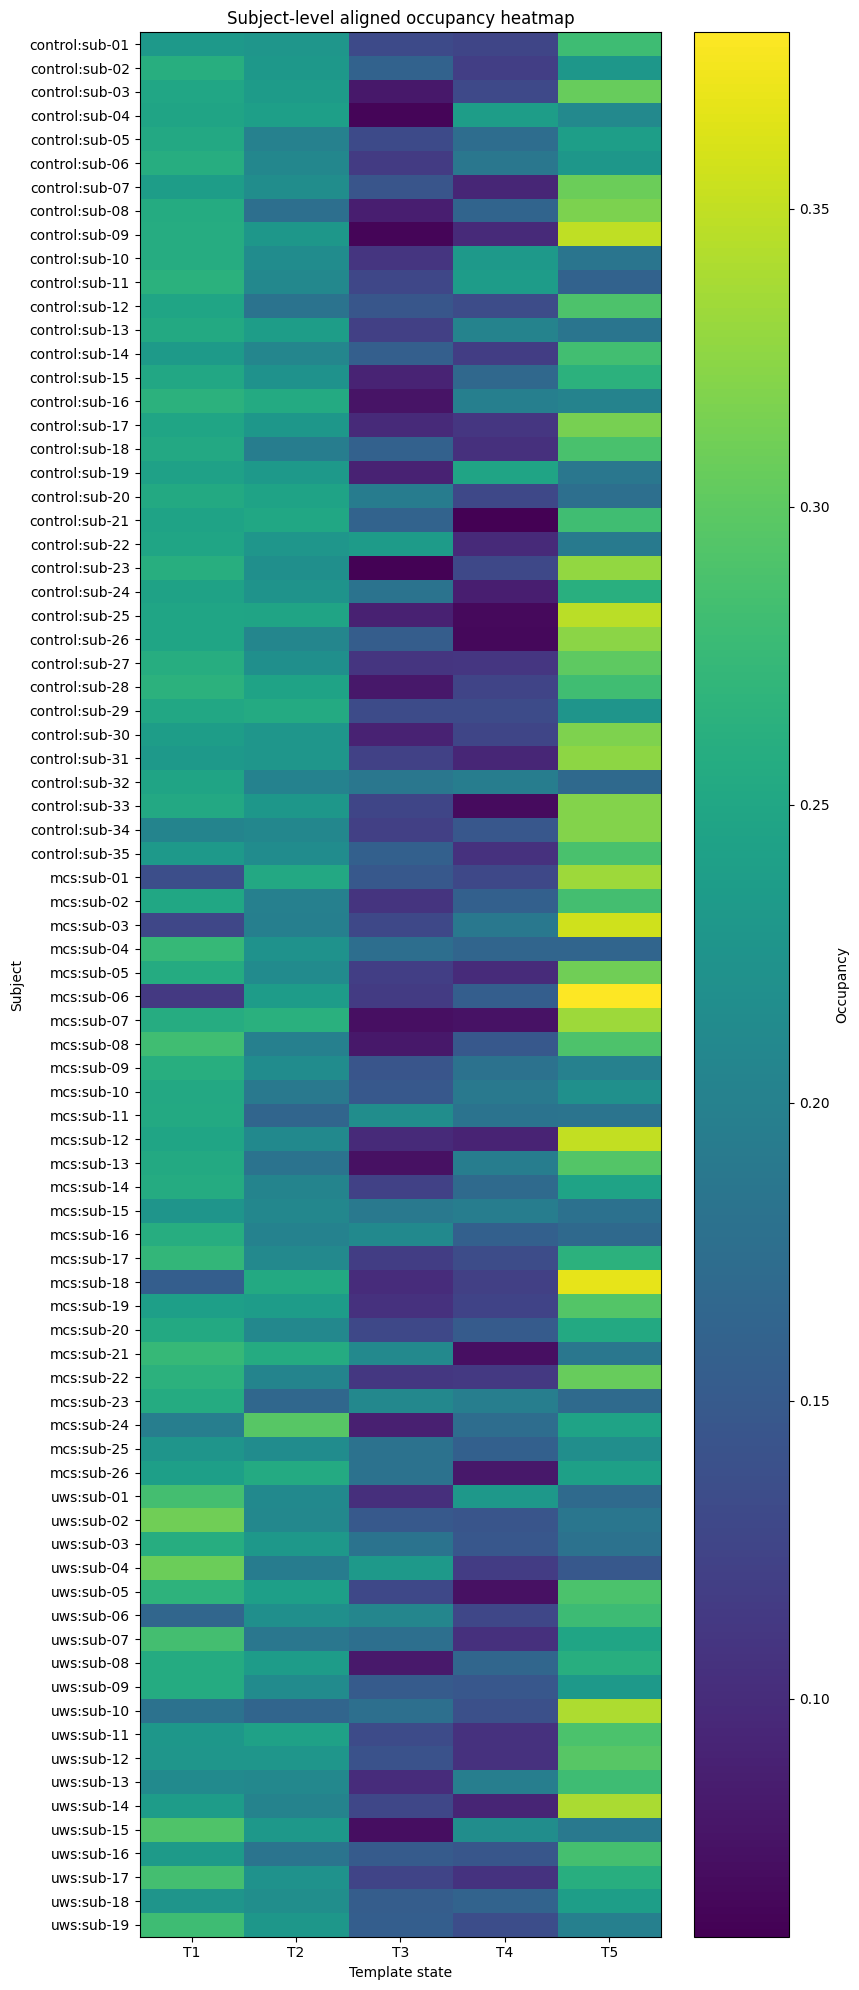

In [9]:
# Heatmap 1: subject x SF-rank occupancy
heat_occ = (
    subject_rank_df
    .pivot_table(index=['cohort', 'subject_id'], columns='sf_rank', values='occupancy_subject_mean')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8.8, max(4.0, 0.25 * heat_occ.shape[0])))
im = ax.imshow(heat_occ.to_numpy(dtype=float), aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(K_STATES), [f'R{r+1}' for r in range(K_STATES)])
ax.set_yticks(np.arange(heat_occ.shape[0]), [f'{c}:{s}' for c, s in heat_occ.index])
ax.set_title('Subject-level occupancy by SF-coupling rank')
ax.set_xlabel('SF-coupling rank (low → high)')
ax.set_ylabel('Subject')
fig.colorbar(im, ax=ax, label='Occupancy')
fig.tight_layout()
fig.savefig(FIG_ROOT / f'subject_level_occupancy_heatmap_sfc_rank_k{K_STATES}.png', dpi=220)
plt.show()

# Heatmap 2: assignment probability P(template type | SF rank), per cohort
fig, axes = plt.subplots(1, len(COHORTS), figsize=(4.2 * len(COHORTS), 3.9), sharey=True)
if len(COHORTS) == 1:
    axes = [axes]

for ax, cohort in zip(axes, COHORTS):
    d = subject_rank_template_df[subject_rank_template_df['cohort'] == cohort]
    tab = d.pivot_table(index='sf_rank', columns='template_state', values='assignment_fraction', aggfunc='mean', fill_value=0.0)
    tab = tab.reindex(index=np.arange(K_STATES), columns=np.arange(K_STATES), fill_value=0.0)
    arr = tab.to_numpy(dtype=float)

    im = ax.imshow(arr, aspect='auto', cmap='magma', vmin=0.0, vmax=1.0)
    ax.set_xticks(np.arange(K_STATES), [f'T{t+1}' for t in range(K_STATES)])
    ax.set_yticks(np.arange(K_STATES), [f'R{r+1}' for r in range(K_STATES)])
    ax.set_title(cohort.upper())
    ax.set_xlabel('Canonical template type')
    if cohort == COHORTS[0]:
        ax.set_ylabel('SF-coupling rank (low → high)')

fig.colorbar(im, ax=axes, label='Mean assignment probability')
fig.tight_layout()
fig.savefig(FIG_ROOT / f'sfc_rank_template_assignment_probability_k{K_STATES}.png', dpi=220)
plt.show()

# Heatmap 3: occupancy carried by each template type at each SF rank, per cohort
fig, axes = plt.subplots(1, len(COHORTS), figsize=(4.2 * len(COHORTS), 3.9), sharey=True)
if len(COHORTS) == 1:
    axes = [axes]

for ax, cohort in zip(axes, COHORTS):
    d = cohort_rank_template_occ_df[cohort_rank_template_occ_df['cohort'] == cohort]
    tab = d.pivot_table(index='sf_rank', columns='template_state', values='mean_occupancy', aggfunc='mean', fill_value=0.0)
    tab = tab.reindex(index=np.arange(K_STATES), columns=np.arange(K_STATES), fill_value=0.0)
    arr = tab.to_numpy(dtype=float)

    im = ax.imshow(arr, aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(K_STATES), [f'T{t+1}' for t in range(K_STATES)])
    ax.set_yticks(np.arange(K_STATES), [f'R{r+1}' for r in range(K_STATES)])
    ax.set_title(cohort.upper())
    ax.set_xlabel('Canonical template type')
    if cohort == COHORTS[0]:
        ax.set_ylabel('SF-coupling rank (low → high)')

fig.colorbar(im, ax=axes, label='Mean occupancy')
fig.tight_layout()
fig.savefig(FIG_ROOT / f'sfc_rank_template_occupancy_matrix_k{K_STATES}.png', dpi=220)
plt.show()



# Matrix small-multiples: rows=template type, cols=SF rank
cohort_colors = {'control': '#4C78A8', 'mcs': '#F58518', 'uws': '#54A24B'}
fig, axes = plt.subplots(K_STATES, K_STATES, figsize=(3.0 * K_STATES, 2.25 * K_STATES), sharex=True, sharey=True)

for t in range(K_STATES):
    for r in range(K_STATES):
        ax = axes[t, r]
        d = subject_rank_template_df[
            (subject_rank_template_df['template_state'] == t) &
            (subject_rank_template_df['sf_rank'] == r)
        ]

        for ci, c in enumerate(COHORTS):
            dc = d[d['cohort'] == c]
            if dc.empty:
                continue
            ys = dc['occupancy_subject_mean'].to_numpy(dtype=float)
            xs = np.full(ys.size, ci, dtype=float) + jitter(ys.size, width=0.06, seed=700 + 50 * t + 7 * r + ci)
            ax.scatter(xs, ys, s=18, alpha=0.72, color=cohort_colors[c], edgecolor='black', linewidth=0.25)

            med = np.median(ys)
            q1 = np.percentile(ys, 25)
            q3 = np.percentile(ys, 75)
            ax.plot([ci - 0.16, ci + 0.16], [med, med], color='black', lw=1.0)
            ax.vlines(ci, q1, q3, color='black', lw=0.8)

        if t == 0:
            ax.set_title(f'SF rank {r + 1}', fontsize=10)
        if r == 0:
            ax.set_ylabel(f'Template {t + 1}\nOccupancy', fontsize=9)

        if t == K_STATES - 1:
            ax.set_xticks(np.arange(len(COHORTS)), [c.upper() for c in COHORTS], rotation=35, ha='right')
        else:
            ax.set_xticks([])

        ax.grid(alpha=0.2)

cohort_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=cohort_colors[c], markeredgecolor='black',
               markeredgewidth=0.3, label=c.upper(), markersize=6)
    for c in COHORTS
]
fig.legend(handles=cohort_handles, loc='upper center', ncol=len(COHORTS), frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('Occupancy matrix by canonical template (rows) and SF rank (columns)', y=1.03)
fig.tight_layout()
fig.savefig(FIG_ROOT / f'subject_level_occupancy_matrix_template_by_sfrank_k{K_STATES}.png', dpi=240)
plt.show()




# Continuous SF-coupling vs occupancy (no discrete x-axis bins)
cohort_colors = {'control': '#4C78A8', 'mcs': '#F58518', 'uws': '#E45756'}
plot_df = aligned_seed_df[['cohort', 'subject_id', 'seed', 'template_state', 'sf_coupling', 'occupancy_template']].copy()
plot_df = plot_df.rename(columns={'occupancy_template': 'occupancy'})
plot_df = plot_df[np.isfinite(plot_df['sf_coupling']) & np.isfinite(plot_df['occupancy'])]

fig, ax = plt.subplots(figsize=(9.0, 6.0))
for cohort in COHORTS:
    d = plot_df[plot_df['cohort'] == cohort]
    if d.empty:
        continue

    x = d['sf_coupling'].to_numpy(dtype=float)
    y = d['occupancy'].to_numpy(dtype=float)
    c = cohort_colors.get(cohort, '#666666')

    ax.scatter(x, y, s=24, alpha=0.38, color=c, edgecolor='none', label=f'{cohort.upper()} samples')

    # Cohort-wise linear trend
    if x.size >= 2 and np.std(x) > 0.0:
        pfit = np.polyfit(x, y, deg=1)
        xx = np.linspace(float(np.min(x)), float(np.max(x)), 200)
        yy = pfit[0] * xx + pfit[1]
        r = np.corrcoef(x, y)[0, 1]
        ax.plot(xx, yy, color=c, lw=2.3, alpha=0.95, label=f'{cohort.upper()} trend (r={r:.2f})')

ax.set_xlabel('SF coupling (subject-specific, continuous)')
ax.set_ylabel('Occupancy rate')
ax.set_title('SF coupling vs occupancy (subject-specific states, continuous axis)')
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_ROOT / f'subject_level_sfc_vs_occupancy_continuous_k{K_STATES}.png', dpi=240)
plt.show()



# Separate condition figures: damage-coded SF-vs-occupancy and explicit damage-association panels
cond_colors = {'control': '#4C78A8', 'mcs': '#F58518', 'uws': '#E45756'}
damage_assoc_rows = []

for cohort in COHORTS:
    d_all = subject_template_df[subject_template_df['cohort'] == cohort].copy()
    d_all = d_all[np.isfinite(d_all['sc_damage_fraction']) & np.isfinite(d_all['sf_coupling_subject_mean']) & np.isfinite(d_all['occupancy_subject_mean'])]
    if d_all.empty:
        continue

    # Figure A: continuous SF coupling vs occupancy, points coloured by subject damage fraction.
    fig, ax = plt.subplots(figsize=(8.2, 6.0))
    sca = ax.scatter(
        d_all['sf_coupling_subject_mean'].to_numpy(dtype=float),
        d_all['occupancy_subject_mean'].to_numpy(dtype=float),
        c=d_all['sc_damage_fraction'].to_numpy(dtype=float),
        cmap='viridis',
        s=36,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.25,
    )

    # Cohort-level trend line
    x = d_all['sf_coupling_subject_mean'].to_numpy(dtype=float)
    y = d_all['occupancy_subject_mean'].to_numpy(dtype=float)
    if x.size >= 2 and np.std(x) > 0:
        pfit = np.polyfit(x, y, deg=1)
        xx = np.linspace(float(np.min(x)), float(np.max(x)), 200)
        yy = pfit[0] * xx + pfit[1]
        rxy = np.corrcoef(x, y)[0, 1]
        ax.plot(xx, yy, color=cond_colors.get(cohort, '#666666'), lw=2.4, alpha=0.95, label=f'Trend (r={rxy:.2f})')

    cbar = fig.colorbar(sca, ax=ax)
    cbar.set_label('Subject SC damage fraction (zero-edge proportion)')
    ax.set_xlabel('SF coupling (subject-specific)')
    ax.set_ylabel('Occupancy rate')
    ax.set_title(f'{cohort.upper()}: SF coupling vs occupancy (coloured by SC damage)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f'{cohort}_sfc_vs_occupancy_damage_coloured_k{K_STATES}.png', dpi=240)
    plt.show()

    # Figure B: Damage associations per template state (specific-state effects)
    fig, axes = plt.subplots(2, K_STATES, figsize=(3.0 * K_STATES, 6.0), sharex='col')
    for t in range(K_STATES):
        dt = d_all[d_all['template_state'] == t].copy()
        if dt.empty:
            continue

        xd = dt['sc_damage_fraction'].to_numpy(dtype=float)
        ysfc = dt['sf_coupling_subject_mean'].to_numpy(dtype=float)
        yocc = dt['occupancy_subject_mean'].to_numpy(dtype=float)

        # Top row: damage -> SF coupling
        ax0 = axes[0, t]
        ax0.scatter(xd, ysfc, s=28, color=cond_colors.get(cohort, '#666666'), alpha=0.78, edgecolor='black', linewidth=0.25)
        if xd.size >= 3 and np.std(xd) > 0 and np.std(ysfc) > 0:
            p0 = np.polyfit(xd, ysfc, deg=1)
            xx0 = np.linspace(float(np.min(xd)), float(np.max(xd)), 120)
            yy0 = p0[0] * xx0 + p0[1]
            rho0, pval0 = spearmanr(xd, ysfc)
            ax0.plot(xx0, yy0, color='black', lw=1.7)
            ax0.text(0.03, 0.96, f'rho={rho0:.2f}\np={pval0:.3g}', transform=ax0.transAxes, va='top', fontsize=8)
            damage_assoc_rows.append({
                'cohort': cohort,
                'template_state': int(t),
                'outcome': 'sf_coupling',
                'n': int(xd.size),
                'spearman_rho': float(rho0),
                'p_value': float(pval0),
                'slope': float(p0[0]),
            })
        ax0.set_title(f'Template {t + 1}')
        if t == 0:
            ax0.set_ylabel('SF coupling')
        ax0.grid(alpha=0.2)

        # Bottom row: damage -> occupancy
        ax1 = axes[1, t]
        ax1.scatter(xd, yocc, s=28, color=cond_colors.get(cohort, '#666666'), alpha=0.78, edgecolor='black', linewidth=0.25)
        if xd.size >= 3 and np.std(xd) > 0 and np.std(yocc) > 0:
            p1 = np.polyfit(xd, yocc, deg=1)
            xx1 = np.linspace(float(np.min(xd)), float(np.max(xd)), 120)
            yy1 = p1[0] * xx1 + p1[1]
            rho1, pval1 = spearmanr(xd, yocc)
            ax1.plot(xx1, yy1, color='black', lw=1.7)
            ax1.text(0.03, 0.96, f'rho={rho1:.2f}\np={pval1:.3g}', transform=ax1.transAxes, va='top', fontsize=8)
            damage_assoc_rows.append({
                'cohort': cohort,
                'template_state': int(t),
                'outcome': 'occupancy',
                'n': int(xd.size),
                'spearman_rho': float(rho1),
                'p_value': float(pval1),
                'slope': float(p1[0]),
            })
        if t == 0:
            ax1.set_ylabel('Occupancy')
        ax1.set_xlabel('SC damage fraction')
        ax1.grid(alpha=0.2)

    fig.suptitle(f'{cohort.upper()}: effect of structural damage on SF coupling and occupancy by template state', y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f'{cohort}_damage_vs_sfc_occupancy_by_template_k{K_STATES}.png', dpi=240)
    plt.show()

damage_assoc_df = pd.DataFrame(damage_assoc_rows)
if not damage_assoc_df.empty:
    display(damage_assoc_df.sort_values(['cohort', 'outcome', 'template_state']).reset_index(drop=True))




## Statistics (unpaired cohorts, subject level)

Includes:
- LZc/PCI cohort differences
- occupancy differences by SF rank
- template-distance differences by canonical template type

In [10]:
# LZc/PCI subject-level stats
lzc_by = {c: subject_metrics_df.loc[subject_metrics_df['cohort'] == c, 'lzc_subject_mean'].to_numpy(dtype=float) for c in COHORTS}
pci_by = {c: subject_metrics_df.loc[subject_metrics_df['cohort'] == c, 'pci_subject_mean'].to_numpy(dtype=float) for c in COHORTS}

omni_lzc, pair_lzc = cohort_stats_unpaired(lzc_by, 'LZc subject mean')
omni_pci, pair_pci = cohort_stats_unpaired(pci_by, 'PCI subject mean')

display(pd.concat([omni_lzc, omni_pci], ignore_index=True))
display(pd.concat([pair_lzc, pair_pci], ignore_index=True))


,metric,test,H,p
0,LZc subject mean,Kruskal-Wallis,39.652473,2.452307e-09
1,PCI subject mean,Kruskal-Wallis,9.120865,1.045753e-02


,metric,contrast,n_a,n_b,U,p_raw,p_holm,cliffs_delta,median_a,median_b
0,LZc subject mean,control vs mcs,35,26,753.0,1.433187e-05,2.866374e-05,0.654945,0.425315,0.420022
1,LZc subject mean,control vs uws,35,19,636.0,4.057263e-08,1.217179e-07,0.912782,0.425315,0.409443
2,LZc subject mean,mcs vs uws,26,19,380.0,2.328061e-03,2.328061e-03,0.538462,0.420022,0.409443
3,PCI subject mean,control vs mcs,35,26,686.0,7.749451e-04,2.324835e-03,0.507692,0.196901,0.185281
4,PCI subject mean,control vs uws,35,19,381.0,3.846064e-01,7.692129e-01,0.145865,0.196901,0.192113
5,PCI subject mean,mcs vs uws,26,19,214.0,4.551560e-01,7.692129e-01,-0.133603,0.185281,0.192113


In [11]:
# Occupancy stats by SF rank (subject-level means)
omni_occ = []
pair_occ = []
for r in range(K_STATES):
    d = subject_rank_df[subject_rank_df['sf_rank'] == r]
    by = {c: d.loc[d['cohort'] == c, 'occupancy_subject_mean'].to_numpy(dtype=float) for c in COHORTS}
    o, p = cohort_stats_unpaired(by, f'SF rank {r + 1} occupancy')
    omni_occ.append(o)
    pair_occ.append(p)

omni_occ_df = pd.concat(omni_occ, ignore_index=True)
pair_occ_df = pd.concat(pair_occ, ignore_index=True)

display(omni_occ_df)
display(pair_occ_df)

# Template distance stats by canonical type (subject-level means)
omni_dist = []
pair_dist = []
for t in range(K_STATES):
    d = subject_template_df[subject_template_df['template_state'] == t]
    by = {c: d.loc[d['cohort'] == c, 'template_distance_subject_mean'].to_numpy(dtype=float) for c in COHORTS}
    o, p = cohort_stats_unpaired(by, f'Template {t + 1} distance')
    omni_dist.append(o)
    pair_dist.append(p)

omni_dist_df = pd.concat(omni_dist, ignore_index=True)
pair_dist_df = pd.concat(pair_dist, ignore_index=True)

display(omni_dist_df)
display(pair_dist_df)

# Plot template distance summary
fig, axes = plt.subplots(1, K_STATES, figsize=(3.2 * K_STATES, 4.1), sharey=True)
for t in range(K_STATES):
    d = subject_template_df[subject_template_df['template_state'] == t]
    plot_subject_metric(
        axes[t],
        d,
        'template_distance_subject_mean',
        f'Template {t + 1} dist',
        'Distance' if t == 0 else '',
        seed=t + 43,
    )
fig.suptitle('Distance to canonical template centroid by cohort', y=1.02)
fig.tight_layout()
fig.savefig(FIG_ROOT / f'subject_level_template_distance_k{K_STATES}.png', dpi=220)
plt.show()

,metric,test,H,p
0,Template 1 occupancy,Kruskal-Wallis,1.163417,0.558943
1,Template 2 occupancy,Kruskal-Wallis,2.102529,0.349495
2,Template 3 occupancy,Kruskal-Wallis,2.878490,0.237107
3,Template 4 occupancy,Kruskal-Wallis,1.374559,0.502942
4,Template 5 occupancy,Kruskal-Wallis,1.303116,0.521233


,metric,contrast,n_a,n_b,U,p_raw,p_holm,cliffs_delta,median_a,median_b
0,Template 1 occupancy,control vs mcs,35,26,428.0,0.699138,0.937443,-0.059341,0.248963,0.254115
1,Template 1 occupancy,control vs uws,35,19,292.0,0.468721,0.937443,-0.121805,0.248963,0.256256
2,Template 1 occupancy,mcs vs uws,26,19,193.0,0.218913,0.656738,-0.218623,0.254115,0.256256
3,Template 2 occupancy,control vs mcs,35,26,538.5,0.226076,0.678228,0.183516,0.227753,0.211562
4,Template 2 occupancy,control vs uws,35,19,398.5,0.235419,0.678228,0.198496,0.227753,0.217383
5,Template 2 occupancy,mcs vs uws,26,19,243.5,0.945036,0.945036,-0.014170,0.211562,0.217383
6,Template 3 occupancy,control vs mcs,35,26,393.0,0.369767,0.739533,-0.136264,0.121571,0.125318
7,Template 3 occupancy,control vs uws,35,19,240.0,0.095628,0.286885,-0.278195,0.121571,0.149204
8,Template 3 occupancy,mcs vs uws,26,19,213.0,0.441403,0.739533,-0.137652,0.125318,0.149204
9,Template 4 occupancy,control vs mcs,35,26,383.0,0.297064,0.891193,-0.158242,0.126321,0.156664


## Save intermediary aligned-state data

In [12]:
np.savez_compressed(
    INT_ROOT / f'state_templates_k{K_STATES}.npz',
    templates=templates,
    pooled_centers=all_centers_mat,
    template_source=np.array([TEMPLATE_SOURCE]),
)

aligned_seed_df.to_csv(INT_ROOT / f'aligned_seed_template_sfc_rank_k{K_STATES}.csv', index=False)
subject_template_df.to_csv(INT_ROOT / f'subject_template_summary_k{K_STATES}.csv', index=False)
subject_rank_df.to_csv(INT_ROOT / f'subject_sfc_rank_summary_k{K_STATES}.csv', index=False)
subject_rank_template_df.to_csv(INT_ROOT / f'subject_sfc_rank_template_summary_k{K_STATES}.csv', index=False)
cohort_rank_template_occ_df.to_csv(INT_ROOT / f'cohort_sfc_rank_template_occupancy_k{K_STATES}.csv', index=False)
subject_metrics_df.to_csv(INT_ROOT / 'subject_lzc_pci_summary.csv', index=False)
omni_occ_df.to_csv(INT_ROOT / f'stats_omnibus_sfc_rank_occupancy_k{K_STATES}.csv', index=False)
pair_occ_df.to_csv(INT_ROOT / f'stats_pairwise_sfc_rank_occupancy_k{K_STATES}.csv', index=False)
omni_dist_df.to_csv(INT_ROOT / f'stats_omnibus_template_distance_k{K_STATES}.csv', index=False)
pair_dist_df.to_csv(INT_ROOT / f'stats_pairwise_template_distance_k{K_STATES}.csv', index=False)
if 'damage_assoc_df' in globals() and not damage_assoc_df.empty:
    damage_assoc_df.to_csv(INT_ROOT / f'damage_association_by_template_k{K_STATES}.csv', index=False)

# Backward-compatible aliases for previous scripts
aligned_seed_df.to_csv(INT_ROOT / f'aligned_seed_occupancy_k{K_STATES}.csv', index=False)
subject_rank_df.to_csv(INT_ROOT / f'subject_template_occupancy_k{K_STATES}.csv', index=False)
omni_occ_df.to_csv(INT_ROOT / f'stats_omnibus_template_occupancy_k{K_STATES}.csv', index=False)
pair_occ_df.to_csv(INT_ROOT / f'stats_pairwise_template_occupancy_k{K_STATES}.csv', index=False)

print('Saved intermediary outputs to:', INT_ROOT)




Saved intermediary outputs to: /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/brain_act_subject_specific/metrics/state_alignment
